# 🕵️ The Assumption Detective
### Stage 2: Shapiro-Wilk, Kolmogorov-Smirnov & Levene's Test

---

**The scenario:** You're a data detective. Someone hands you a dataset and says *"just run a t-test"* or *"just run ANOVA."*

But here's the catch — **every parametric test makes assumptions about the data.** If those assumptions are false, your test lies to you. It'll still spit out a p-value, looking confident... and it will be **wrong**.

Before Stage 3 (t-test, ANOVA) and Stage 4 (Mann-Whitney, Kruskal-Wallis), you need to play detective and check:

| Question | Test | Detects |
|---|---|---|
| Is my data normally distributed? | **Shapiro-Wilk** | Normality (best for small-medium samples) |
| Does my data match a distribution / another sample? | **Kolmogorov-Smirnov (K-S)** | Distribution shape/location differences |
| Do my groups have equal spread (variance)? | **Levene's Test** | Homogeneity of variance |

Get these three right, and you'll always know *which* test to trust downstream.


## 🔧 Setup

We'll use two classic open datasets baked into `seaborn`:
- **`tips`** — restaurant bills and tips 
- **`penguins`** — physical measurements of 3 penguin species (for later comparisons)

No downloads needed — seaborn ships them.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Make plots a bit nicer
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
sns.set_style("whitegrid")

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()

print("Tips dataset:", tips.shape)
tips.head()


Tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
print("Penguins dataset:", penguins.shape)
penguins.head()


Penguins dataset: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## 1️⃣ Shapiro-Wilk Test — "Is this bell-shaped?"

### The theory

The Shapiro-Wilk test asks one question: **does my sample look like it came from a normal (Gaussian) distribution?**

- **H₀ (null hypothesis):** The data *is* normally distributed.
- **H₁ (alternative):** The data is *not* normally distributed.

It works by comparing the *order statistics* of your sample (the sorted values) to what you'd expect from a perfect normal distribution, producing a test statistic **W** (between 0 and 1 — closer to 1 = more normal-looking).

### How to read the result

| p-value | Decision |
|---|---|
| p > 0.05 | Fail to reject H₀ → data looks normal ✅ |
| p ≤ 0.05 | Reject H₀ → data is **not** normal ⚠️ |

### ⚠️ The catch every student misses

Shapiro-Wilk is **very sensitive with large samples**. With thousands of rows, it will flag even tiny, harmless deviations from normality as "significant." Always **look at the data visually too** (histogram, Q-Q plot) — don't blindly trust the p-value in big datasets.

> 💡 Rule of thumb: Shapiro-Wilk works best for samples roughly between 3 and 5,000. Beyond that, lean more on visual inspection.


In [3]:
# Case #1: Is the "total_bill" column normally distributed?
bill = tips['total_bill']

stat, p_value = stats.shapiro(bill)
print(f"Shapiro-Wilk Statistic (W): {stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value > 0.05:
    print("Verdict: Fail to reject H0 -> Data looks normally distributed")
else:
    print("Verdict: Reject H0 -> Data is NOT normally distributed")


Shapiro-Wilk Statistic (W): 0.9197
p-value: 0.000000
Verdict: Reject H0 -> Data is NOT normally distributed


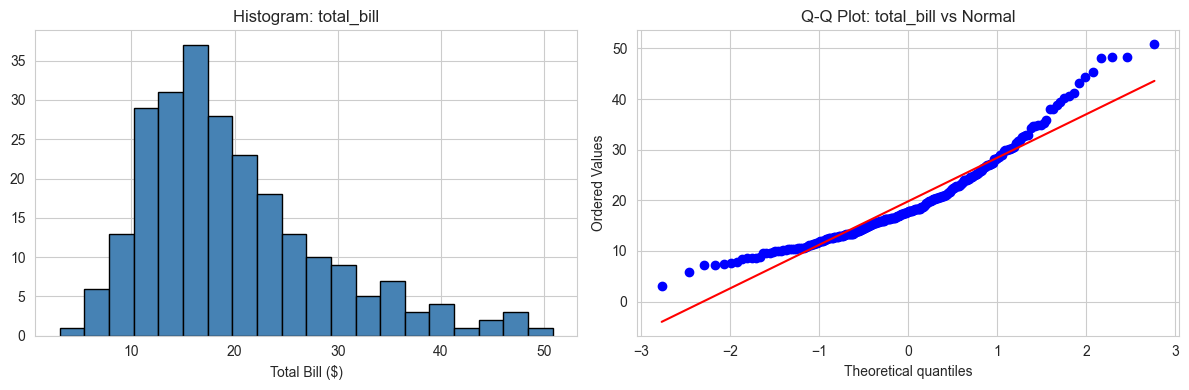

In [4]:
# Let's SEE why -- never trust a p-value blindly
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(bill, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title("Histogram: total_bill")
axes[0].set_xlabel("Total Bill ($)")

stats.probplot(bill, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: total_bill vs Normal")

plt.tight_layout()
plt.show()


**What you should notice:** the histogram is skewed right (a long tail of expensive bills), and the Q-Q plot points curve away from the diagonal line at the tails. This is *exactly* what a low Shapiro-Wilk p-value is warning you about — the data is not symmetric/bell-shaped.

### 🎯 Quick challenge
Run the same test on the `tip` column. Is it normal? What about `tip` values *only for dinner* (`time == "Dinner"`)? Try it in the cell below before scrolling further.


In [6]:
# Your turn: test normality of the 'tip' column
tip_stat, p_value = stats.shapiro(tips['tip'])

print(f"Shapiro-Wilk on 'tip': W={tip_stat:.4f}, p={p_value:.6f}")

if p_value > 0.05:
    print("Verdict: Fail to reject H0 -> Data looks normally distributed")
else:
    print("Verdict: Reject H0 -> Data is NOT normally distributed")


Shapiro-Wilk on 'tip': W=0.8978, p=0.000000
Verdict: Reject H0 -> Data is NOT normally distributed


In [7]:
# Bonus: only dinner tips
dinner_tips = tips.loc[tips['time'] == 'Dinner', 'tip']
d_stat, p_value = stats.shapiro(dinner_tips)
print(f"Shapiro-Wilk on Dinner-only 'tip': W={d_stat:.4f}, p={p_value:.6f}")

if p_value > 0.05:
    print("Verdict: Fail to reject H0 -> Data looks normally distributed")
else:
    print("Verdict: Reject H0 -> Data is NOT normally distributed")


Shapiro-Wilk on Dinner-only 'tip': W=0.9009, p=0.000000
Verdict: Reject H0 -> Data is NOT normally distributed


## 2️⃣ Kolmogorov-Smirnov (K-S) Test — "Does this match a known shape, or another sample?"

### The theory

The K-S test is more flexible than Shapiro-Wilk — it compares the **cumulative distribution function (CDF)** of your data against either:

1. **A theoretical distribution** (one-sample K-S) — e.g., "is this normal? is this uniform?"
2. **Another sample's distribution** (two-sample K-S) — e.g., "do lunch tips and dinner tips come from the same distribution?"

It computes **D**, the maximum vertical distance between the two CDFs:

$$D = \sup_x |F_1(x) - F_2(x)|$$

- **H₀:** The two distributions are the same (or the sample matches the theoretical distribution).
- **H₁:** They differ.

### Shapiro-Wilk vs K-S — what's the actual difference?

| | Shapiro-Wilk | Kolmogorov-Smirnov |
|---|---|---|
| Tests against | Only normal distribution | Any distribution (normal, uniform, exponential...) |
| Can compare 2 samples? | ❌ No | ✅ Yes (two-sample K-S) |
| Sensitivity | Better power for detecting non-normality | Generally less powerful for normality specifically |
| Best use case | "Is my single sample normal?" | "Do these two groups have the same distribution?" |

> 💡 In practice: use **Shapiro-Wilk** as your go-to normality check, and use **K-S (two-sample)** when you want to compare two groups' entire distributions — not just their means.


In [8]:
# One-sample K-S: is total_bill normal? (compare to a normal with same mean/std)
mean_bill, std_bill = bill.mean(), bill.std()

ks_stat, ks_p = stats.kstest(bill, 'norm', args=(mean_bill, std_bill))
print(f"One-sample K-S Statistic (D): {ks_stat:.4f}")
print(f"p-value: {ks_p:.6f}")

if ks_p > 0.05:
    print("Verdict: Fail to reject H0 -> Matches a normal distribution")
else:
    print("Verdict: Reject H0 -> Does NOT match a normal distribution")


One-sample K-S Statistic (D): 0.1188
p-value: 0.001866
Verdict: Reject H0 -> Does NOT match a normal distribution


Notice K-S agrees with Shapiro-Wilk here — good, our tools are consistent. Now let's use the **two-sample** version for something more interesting: comparing **Lunch vs Dinner tip distributions**.


In [9]:
lunch_tips = tips.loc[tips['time'] == 'Lunch', 'tip']
dinner_tips = tips.loc[tips['time'] == 'Dinner', 'tip']

ks_stat2, ks_p2 = stats.ks_2samp(lunch_tips, dinner_tips)
print(f"Two-sample K-S Statistic (D): {ks_stat2:.4f}")
print(f"p-value: {ks_p2:.6f}")

if ks_p2 > 0.05:
    print("Verdict: Fail to reject H0 -> Lunch and Dinner tips likely come from the same distribution")
else:
    print("Verdict: Reject H0 -> Lunch and Dinner tips come from DIFFERENT distributions")


Two-sample K-S Statistic (D): 0.2186
p-value: 0.015221
Verdict: Reject H0 -> Lunch and Dinner tips come from DIFFERENT distributions


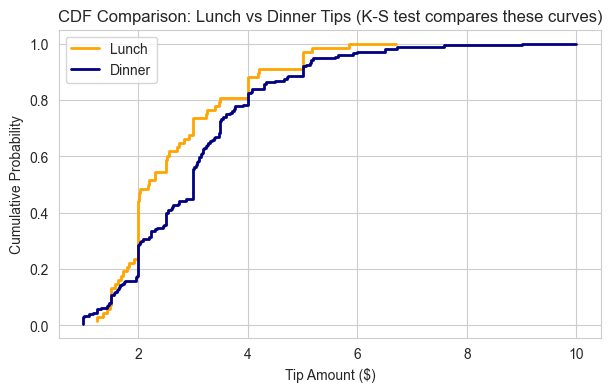

In [10]:
# Visualize the CDFs -- this IS what the K-S test is measuring
fig, ax = plt.subplots(figsize=(7, 4))

for data, label, color in [(lunch_tips, 'Lunch', 'orange'), (dinner_tips, 'Dinner', 'navy')]:
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    ax.step(sorted_data, cdf, label=label, color=color, linewidth=2)

ax.set_xlabel("Tip Amount ($)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("CDF Comparison: Lunch vs Dinner Tips (K-S test compares these curves)")
ax.legend()
plt.show()


**What you should notice:** the K-S statistic D is literally the biggest vertical gap between those two step curves. If the curves overlap almost perfectly → high p-value → same distribution. If they diverge a lot at some point → low p-value → different distributions.

### 🎯 Quick challenge
Use the two-sample K-S test to compare `total_bill` between `Male` and `Female` customers (the `sex` column). Are their spending patterns from the same distribution?


In [11]:
male_bills = tips.loc[tips['sex'] == 'Male', 'total_bill']
female_bills = tips.loc[tips['sex'] == 'Female', 'total_bill']

stat, p = stats.ks_2samp(male_bills, female_bills)
print(f"K-S Statistic: {stat:.4f}, p-value: {p:.6f}")

K-S Statistic: 0.2003, p-value: 0.018708


## 3️⃣ Levene's Test — "Do these groups have the same spread?"

### The theory

Many tests (like the classic Student's t-test and one-way ANOVA) assume **homogeneity of variance** — i.e., all groups being compared have roughly the same "spread" of values, even if their averages differ.

Levene's test checks exactly that:

- **H₀:** All group variances are equal (homogeneity of variance holds).
- **H₁:** At least one group has a different variance.

### How it actually works (intuition, not just formula)

Levene's test transforms each value into its **absolute deviation from its group's median (or mean)**, then runs a one-way ANOVA on *those deviations*. Big deviations in one group but small in another → unequal spread → significant result.

### Why this matters downstream

| Levene's result | What to do next |
|---|---|
| p > 0.05 (equal variances) | Use standard t-test / ANOVA |
| p ≤ 0.05 (unequal variances) | Use **Welch's t-test** (unequal variance) or be cautious with ANOVA, or consider non-parametric alternatives |

> 💡 This is your bridge to Stage 3! Once you know if variances are equal, you know exactly which flavor of t-test/ANOVA to trust.


In [12]:
# Case: do Smokers and Non-Smokers have equal variance in total_bill?
smoker_bills = tips.loc[tips['smoker'] == 'Yes', 'total_bill']
nonsmoker_bills = tips.loc[tips['smoker'] == 'No', 'total_bill']

lev_stat, lev_p = stats.levene(smoker_bills, nonsmoker_bills)
print(f"Levene's Statistic: {lev_stat:.4f}")
print(f"p-value: {lev_p:.6f}")

if lev_p > 0.05:
    print("Verdict: Fail to reject H0 -> Variances are roughly EQUAL")
else:
    print("Verdict: Reject H0 -> Variances are significantly DIFFERENT")


Levene's Statistic: 4.0537
p-value: 0.045181
Verdict: Reject H0 -> Variances are significantly DIFFERENT


Variance (Smoker):     96.67
Variance (Non-Smoker): 68.15


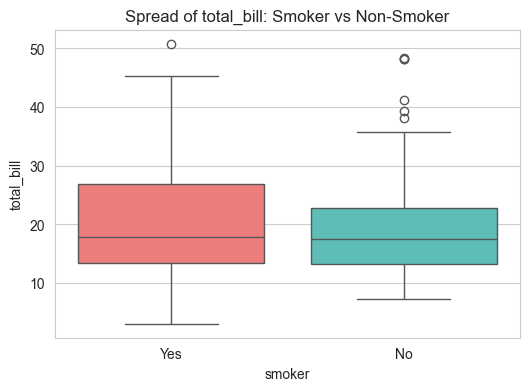

In [13]:
# Visualize the spread difference with boxplots + variance annotation
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=tips, x='smoker', y='total_bill', hue='smoker',
            palette=['#ff6b6b', '#4ecdc4'], ax=ax, legend=False)
ax.set_title("Spread of total_bill: Smoker vs Non-Smoker")

print(f"Variance (Smoker):     {smoker_bills.var():.2f}")
print(f"Variance (Non-Smoker): {nonsmoker_bills.var():.2f}")
plt.show()


### Levene's test with MORE than 2 groups — the penguins!

Levene's test isn't limited to 2 groups — it scales to many, which is exactly what you need before running **ANOVA** (Stage 3) across 3+ groups.


In [14]:
# Do the 3 penguin species have equal variance in body_mass_g?
adelie = penguins.loc[penguins['species'] == 'Adelie', 'body_mass_g']
chinstrap = penguins.loc[penguins['species'] == 'Chinstrap', 'body_mass_g']
gentoo = penguins.loc[penguins['species'] == 'Gentoo', 'body_mass_g']

lev_stat3, lev_p3 = stats.levene(adelie, chinstrap, gentoo)
print(f"Levene's Statistic: {lev_stat3:.4f}")
print(f"p-value: {lev_p3:.6f}")

if lev_p3 > 0.05:
    print("Verdict: Equal variances across all 3 species -> Safe for standard ANOVA")
else:
    print("Verdict: Unequal variances -> Consider Welch's ANOVA or Kruskal-Wallis instead")


Levene's Statistic: 5.1349
p-value: 0.006367
Verdict: Unequal variances -> Consider Welch's ANOVA or Kruskal-Wallis instead


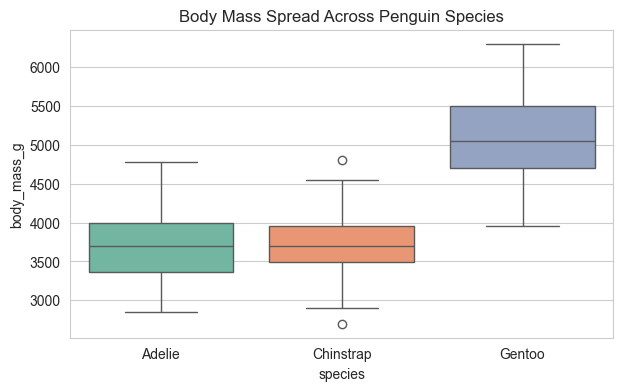

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=penguins, x='species', y='body_mass_g', hue='species',
            palette='Set2', ax=ax, legend=False)
ax.set_title("Body Mass Spread Across Penguin Species")
plt.show()


### 🎯 Quick challenge
Check whether variance in `bill_length_mm` is equal across the 3 penguin species. What's your verdict, and what test would you recommend for Stage 3 based on it?


In [16]:
a_bill = penguins.loc[penguins['species'] == 'Adelie', 'bill_length_mm']
c_bill = penguins.loc[penguins['species'] == 'Chinstrap', 'bill_length_mm']
g_bill = penguins.loc[penguins['species'] == 'Gentoo', 'bill_length_mm']

stat, p = stats.levene(a_bill, c_bill, g_bill)
print(f"Levene's Statistic: {stat:.4f}, p-value: {p:.6f}")


Levene's Statistic: 2.2855, p-value: 0.103328


## 🧭 Putting It All Together — The Decision Map

Before you run ANY test in Stage 3/4, walk through this checklist:

```
START
  │
  ├── Is my variable continuous?
  │      │
  │      ├── Check NORMALITY (Shapiro-Wilk, or K-S for larger n)
  │      │      │
  │      │      ├── Normal? ──► Check homogeneity of VARIANCE (Levene's)
  │      │      │                   │
  │      │      │                   ├── Equal variance ──► Standard t-test / ANOVA
  │      │      │                   └── Unequal variance ─► Welch's t-test / Welch's ANOVA
  │      │      │
  │      │      └── Not Normal? ──► Non-parametric route
  │      │                              (Mann-Whitney U / Kruskal-Wallis — Stage 4)
  │
  └── Comparing 2 whole distributions (shape, not just mean)?
         └── Use two-sample Kolmogorov-Smirnov
```

### 📋 Cheat Sheet

| Test | Checks | H₀ | Use before |
|---|---|---|---|
| **Shapiro-Wilk** | Normality of ONE sample | Data is normal | t-test, ANOVA, Pearson correlation |
| **Kolmogorov-Smirnov** | Match to a distribution OR compare 2 samples' shapes | Same distribution | Confirming normality; comparing full distributions |
| **Levene's Test** | Equal variance across 2+ groups | Variances are equal | Choosing standard vs Welch's t-test/ANOVA |


## 🏆 Final Case File — Solve It Yourself

You're handed a new question: *"Do Male and Female customers tip proportionally the same, and can I safely run a standard t-test to compare their average tips?"*

Your job, step by step:
1. Check normality of `tip` separately for Male and Female customers (Shapiro-Wilk).
2. Check equality of variance between the two groups (Levene's Test).
3. Based on both results, write your recommendation: standard t-test, Welch's t-test, or a non-parametric test (Mann-Whitney U — coming in Stage 4)?

Use the empty cell below to investigate. This is exactly the workflow you'll repeat for every real analysis.


In [17]:
# 🔍 Your investigation starts here
male_tip = tips.loc[tips['sex'] == 'Male', 'tip']
female_tip = tips.loc[tips['sex'] == 'Female', 'tip']

# Step 1: Normality checks
print("--- Shapiro-Wilk: Male tips ---")
print(stats.shapiro(male_tip))

print("--- Shapiro-Wilk: Female tips ---")
print(stats.shapiro(female_tip))

# Step 2: Variance check
print("--- Levene's Test ---")
print(stats.levene(male_tip, female_tip))

# Step 3: Your recommendation (write as a comment)
# TODO: based on the p-values above, what test would you recommend and why?


--- Shapiro-Wilk: Male tips ---
ShapiroResult(statistic=0.8758690617789388, pvalue=3.7084828294513925e-10)
--- Shapiro-Wilk: Female tips ---
ShapiroResult(statistic=0.9567775372726819, pvalue=0.005448280473692281)
--- Levene's Test ---
LeveneResult(statistic=1.9909710178779405, pvalue=0.15952363598966007)


---
## 📝 Recap

- **Shapiro-Wilk** → "Is my single sample normal?" — your default normality check for small/medium samples.
- **Kolmogorov-Smirnov** → "Does my sample match a distribution, or match another sample?" — more flexible, works for two-sample comparisons.
- **Levene's Test** → "Do my groups have equal spread?" — the gatekeeper before choosing standard vs. Welch's t-test/ANOVA.
